Epoch 0 - Loss: 0.4418


/tmp/ipython-input-1935593580.py:52: RuntimeWarning: overflow encountered in exp
  s = 1 / (1 + np.exp(-x))


Epoch 300 - Loss: 0.2321
Epoch 600 - Loss: 0.2128
Epoch 900 - Loss: 0.2402
Epoch 1200 - Loss: 0.2322
Epoch 1500 - Loss: 0.2512
Epoch 1800 - Loss: 0.2379
Epoch 2100 - Loss: 0.2737
Epoch 2400 - Loss: 0.2604


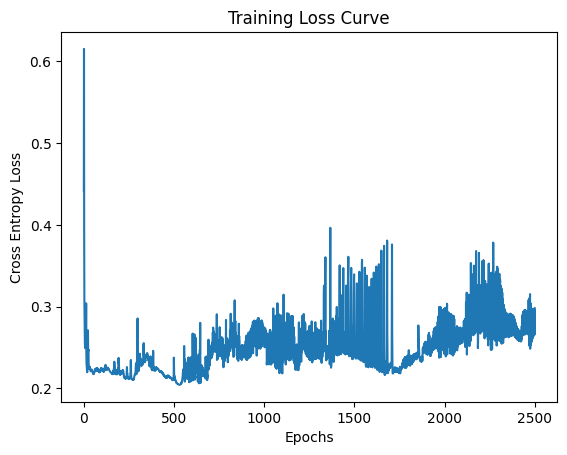

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



========= Evaluation Metrics =========
Accuracy: 0.664

Precision per class: [0.         0.         0.65555556 0.71212121 0.63829787]
Recall per class: [0.         0.         1.         0.87037037 0.98360656]
F1-score per class: [0.         0.         0.79194631 0.78333333 0.77419355]


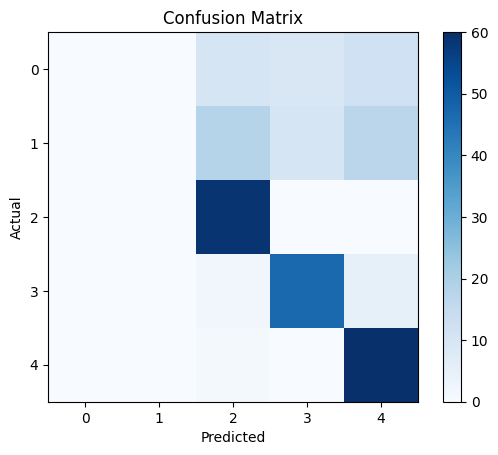

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------
#   1. Synthetic Dataset (5 Classes)
# -----------------------------------------------------------
np.random.seed(0)

N = 1000
X = np.random.randn(N, 2) * 1.5
Y = np.zeros((N, 5))      # One-hot labels (5 classes)

for i in range(N):
    x, y = X[i]
    r = np.sqrt(x**2 + y**2)
    angle = np.arctan2(y, x)

    # 5 classes based on radius + angle
    if r < 0.8:
        Y[i, 0] = 1
    elif r < 1.4:
        Y[i, 1] = 1
    elif angle < -1:
        Y[i, 2] = 1
    elif angle < 1:
        Y[i, 3] = 1
    else:
        Y[i, 4] = 1

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

# -----------------------------------------------------------
#   2. Neural Network (3 Hidden Layers, Softmax Output)
# -----------------------------------------------------------
class NeuralNetwork:
    def __init__(self):
        self.learning_rate = 0.01

        # 3 hidden layers
        self.W1 = np.random.randn(2, 16)
        self.W2 = np.random.randn(16, 12)
        self.W3 = np.random.randn(12, 10)
        self.W4 = np.random.randn(10, 5)  # 5 output classes

    # -------------------------
    # Activation Functions
    # -------------------------
    def sigmoid(self, x, der=False):
        s = 1 / (1 + np.exp(-x))
        if der:
            return s * (1 - s)
        return s

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    # -------------------------
    # Forward Pass
    # -------------------------
    def feedForward(self, X):
        self.z1 = np.dot(X, self.W1)
        self.a1 = self.sigmoid(self.z1)

        self.z2 = np.dot(self.a1, self.W2)
        self.a2 = self.sigmoid(self.z2)

        self.z3 = np.dot(self.a2, self.W3)
        self.a3 = self.sigmoid(self.z3)

        self.z4 = np.dot(self.a3, self.W4)
        self.output = self.softmax(self.z4)

        return self.output

    # -------------------------
    # Backpropagation (Cross Entropy)
    # -------------------------
    def backPropagation(self, X, Y, output):

        # Output layer delta (softmax + cross entropy)
        output_delta = (output - Y)

        # Layer 3
        hidden3_error = np.dot(output_delta, self.W4.T)
        hidden3_delta = hidden3_error * self.sigmoid(self.a3, der=True)

        # Layer 2
        hidden2_error = np.dot(hidden3_delta, self.W3.T)
        hidden2_delta = hidden2_error * self.sigmoid(self.a2, der=True)

        # Layer 1
        hidden1_error = np.dot(hidden2_delta, self.W2.T)
        hidden1_delta = hidden1_error * self.sigmoid(self.a1, der=True)

        # Gradient update
        self.W4 -= self.learning_rate * np.dot(self.a3.T, output_delta)
        self.W3 -= self.learning_rate * np.dot(self.a2.T, hidden3_delta)
        self.W2 -= self.learning_rate * np.dot(self.a1.T, hidden2_delta)
        self.W1 -= self.learning_rate * np.dot(X.T, hidden1_delta)

    # -------------------------
    # Training Function
    # -------------------------
    def train(self, X, Y, epochs=3000):
        loss_list = []
        for i in range(epochs):
            output = self.feedForward(X)
            self.backPropagation(X, Y, output)

            loss = -np.mean(Y * np.log(output + 1e-9))
            loss_list.append(loss)

            if i % 300 == 0:
                print(f"Epoch {i} - Loss: {loss:.4f}")

        return loss_list

# -----------------------------------------------------------
#     3. Train Model
# -----------------------------------------------------------
NN = NeuralNetwork()
errors = NN.train(X_train, Y_train, epochs=2500)

plt.plot(errors)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy Loss")
plt.show()

# -----------------------------------------------------------
#     4. Evaluation
# -----------------------------------------------------------
pred_prob = NN.feedForward(X_test)
pred = np.argmax(pred_prob, axis=1)
true = np.argmax(Y_test, axis=1)

acc = accuracy_score(true, pred)
prec, recall, f1, _ = precision_recall_fscore_support(true, pred, average=None)

print("\n========= Evaluation Metrics =========")
print("Accuracy:", acc)
print("\nPrecision per class:", prec)
print("Recall per class:", recall)
print("F1-score per class:", f1)

# Confusion Matrix
cm = confusion_matrix(true, pred)
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
